# 06e — Tuning Comparison, Feature Experiments and Final Model Selection
**RouteRight AI — Stage 7 (Model Optimization and Final Model Selection)**

This notebook reads the results saved by `06a`–`06d` and does the remaining Stage 7 work:

1. **Tuned vs baseline** for all four models (same folds, same metrics).
2. **Tuned models compared with each other**, fold by fold, with paired differences.
3. **Feature experiments** — does removing a suspicious feature help? (Stage 7: "investigate whether feature selection/engineering improves performance".)
4. **Final model selection** with a written justification, and saving the final model.

The only models fitted here are the feature experiments (using each model's already-tuned hyperparameters, no new search) and the final refit. The test set stays sealed until `07_Model_Evaluation.ipynb`.

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import accuracy_score, average_precision_score, f1_score

import baseline_common as bc
import tuning_common as tc

MODELS = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]
X, y, train = bc.load_train(verbose=False)

best = {m: json.loads((tc.TUNE_DIR / f"tuning_{bc.slug(m)}_best.json").read_text()) for m in MODELS}
summ = pd.concat([pd.read_csv(tc.TUNE_DIR / f"tuning_{bc.slug(m)}_summary.csv") for m in MODELS], ignore_index=True)
fold_scores = {m: pd.read_csv(tc.TUNE_DIR / f"tuning_{bc.slug(m)}_best_folds.csv") for m in MODELS}
noskill = pd.read_csv(bc.OUT_DIR / "baseline_cv_summary.csv").query("model.str.startswith('Reference')", engine="python")["pr_auc"].iloc[0]
print("Loaded tuned results for:", MODELS)

Loaded tuned results for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


## 1. Tuned vs baseline
For each model the baseline row is the better of its two baseline variants (unweighted / weighted) on PR-AUC.

In [2]:
rows = []
for m in MODELS:
    d = summ[summ.model == m]
    base = d[d.variant != "tuned"].sort_values("pr_auc", ascending=False).iloc[0]
    tuned = d[d.variant == "tuned"].iloc[0]
    rows.append({"model": m, "baseline_variant": base.variant,
                 "baseline_pr_auc": base.pr_auc, "tuned_pr_auc": tuned.pr_auc, "delta_pr_auc": round(tuned.pr_auc - base.pr_auc, 4),
                 "tuned_pr_auc_std": tuned.pr_auc_std,
                 "baseline_f1": base.f1, "tuned_f1": tuned.f1, "delta_f1": round(tuned.f1 - base.f1, 4),
                 "tuned_recall": tuned.recall, "tuned_precision": tuned.precision,
                 "tuned_accuracy": tuned.accuracy, "tuned_roc_auc": tuned.roc_auc})
gain = pd.DataFrame(rows).sort_values("tuned_pr_auc", ascending=False).reset_index(drop=True)
gain.to_csv(tc.TUNE_DIR / "tuning_baseline_vs_tuned.csv", index=False)
gain

,model,baseline_variant,baseline_pr_auc,tuned_pr_auc,delta_pr_auc,tuned_pr_auc_std,baseline_f1,tuned_f1,delta_f1,tuned_recall,tuned_precision,tuned_accuracy,tuned_roc_auc
0,Random Forest,weighted,0.7374,0.7611,0.0237,0.0472,0.6813,0.6802,-0.0011,0.6731,0.6925,0.7216,0.7881
1,Gradient Boosting,weighted,0.7308,0.7537,0.0229,0.0460,0.6156,0.6739,0.0583,0.6533,0.7079,0.7233,0.7849
2,Logistic Regression,unweighted,0.7178,0.7183,0.0005,0.0735,0.6245,0.6226,-0.0019,0.6225,0.6632,0.6837,0.7509
3,Decision Tree,weighted,0.5515,0.6917,0.1402,0.0414,0.6188,0.6359,0.0171,0.6418,0.6405,0.6786,0.7335


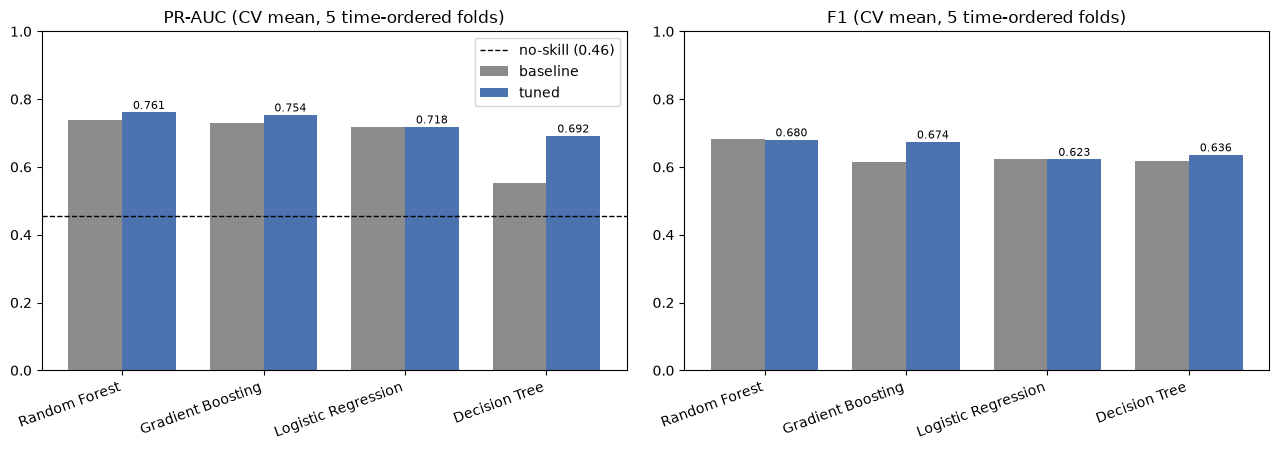

In [3]:
order = gain["model"].tolist()
xs = np.arange(len(order)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, met in zip(axes, ["pr_auc", "f1"]):
    b = gain[f"baseline_{met}"]; t = gain[f"tuned_{met}"]
    ax.bar(xs - w / 2, b, w, label="baseline", color="#8c8c8c")
    ax.bar(xs + w / 2, t, w, label="tuned", color="#4C72B0")
    for i, (bv, tv) in enumerate(zip(b, t)):
        ax.text(i + w / 2, tv + 0.01, f"{tv:.3f}", ha="center", fontsize=8)
    ax.set_xticks(xs); ax.set_xticklabels(order, rotation=20, ha="right"); ax.set_ylim(0, 1)
    ax.set_title(met.upper().replace("_", "-") + " (CV mean, 5 time-ordered folds)")
axes[0].axhline(noskill, color="black", ls="--", lw=1, label=f"no-skill ({noskill:.2f})"); axes[0].legend()
plt.tight_layout(); plt.savefig(tc.TUNE_DIR / "tuning_baseline_vs_tuned.png", dpi=130); plt.show()

## 2. Tuned models compared with each other
Per-fold PR-AUC of every model's best configuration next to the no-skill level of that fold (the positive rate of the validation block). Then **paired** differences against the leader: because all models were evaluated on identical folds, the fold-by-fold difference is a fairer comparison than comparing means with their (large) fold-to-fold spreads.

In [4]:
folds_meta = bc.fold_table(X, y).set_index("fold")
per_fold = pd.DataFrame({m: fold_scores[m].set_index("fold")["pr_auc"] for m in MODELS})
per_fold.insert(0, "no_skill", folds_meta["val_pos_rate"])
per_fold.round(3)

,no_skill,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting
fold,,,,,
1,0.611,0.864,0.742,0.847,0.834
2,0.453,0.700,0.698,0.723,0.723
3,0.426,0.666,0.616,0.714,0.698
4,0.374,0.678,0.697,0.759,0.757
5,0.411,0.684,0.705,0.762,0.756


In [5]:
leader = gain.iloc[0]["model"]
rows = []
for m in MODELS:
    if m == leader:
        continue
    diff = per_fold[leader] - per_fold[m]
    rows.append({"leader": leader, "vs": m, "mean_paired_diff": round(diff.mean(), 4),
                 "std_of_diff": round(diff.std(), 4), "folds_leader_wins": f"{int((diff > 0).sum())} of {len(diff)}",
                 "diff_per_fold": [round(v, 3) for v in diff]})
paired = pd.DataFrame(rows)
paired

,leader,vs,mean_paired_diff,std_of_diff,folds_leader_wins,diff_per_fold
0,Random Forest,Logistic Regression,0.0428,0.0409,4 of 5,"[-0.016, 0.023, 0.048, 0.082, 0.078]"
1,Random Forest,Decision Tree,0.0693,0.0326,5 of 5,"[0.105, 0.025, 0.098, 0.062, 0.057]"
2,Random Forest,Gradient Boosting,0.0074,0.0069,4 of 5,"[0.013, -0.0, 0.016, 0.002, 0.007]"


## 3. Feature experiments
Two suspicions from the baseline stage are tested here, using each model's **already-tuned** hyperparameters (no new search) on the same 5 folds:

* **`priority_encoded`** correlates 0.89–0.91 with `impact_encoded` / `urgency_encoded`; it may be redundant.
* **The time features** (`opened_hour`, `opened_day_of_week`) topped the Decision Tree / Random Forest importances although the README found little linear signal in them — possibly an overfitting artefact. **`opened_month`** is a special case: `train.csv` covers only Feb–May, so month acts as a *time-trend proxy* (reassignment rate falls from ≈ 55% to ≈ 41% over those months). The test set and any future ticket contain months the model never saw, so a model that leans on month may not deploy well even if its CV score is good.

A change counts as an improvement only if the paired fold-by-fold difference is consistently positive and larger than the noise.

In [6]:
ABLATIONS = {
    "all 109 features (reference)": [],
    "drop priority_encoded": ["priority_encoded"],
    "drop opened_month": ["opened_month"],
    "drop hour / weekday / weekend": ["opened_hour", "opened_day_of_week", "opened_is_weekend"],
    "drop all 4 temporal features": ["opened_hour", "opened_day_of_week", "opened_month", "opened_is_weekend"],
}

def build_tuned(model_name):
    """Fresh estimator carrying the best hyperparameters found in 06a-06d."""
    est = tc.build_estimator(model_name)
    prefix = "clf__" if model_name == "Logistic Regression" else ""
    est.set_params(**{prefix + k: v for k, v in best[model_name]["best_params"].items()})
    return est

def cv_scores(model_name, drop_cols):
    per_fold_rows = []
    for k, (tr, va) in enumerate(bc.get_cv().split(X), start=1):
        est = clone(build_tuned(model_name))
        cols = [c for c in X.columns if c not in drop_cols]
        est.fit(X.iloc[tr][cols], y.iloc[tr])
        proba = est.predict_proba(X.iloc[va][cols])[:, 1]
        pred = (proba >= bc.THRESHOLD).astype(int)
        per_fold_rows.append({"fold": k, "pr_auc": average_precision_score(y.iloc[va], proba),
                              "f1": f1_score(y.iloc[va], pred, zero_division=0),
                              "accuracy": accuracy_score(y.iloc[va], pred)})
    return pd.DataFrame(per_fold_rows).set_index("fold")

ablation_rows = []
for m in MODELS:
    ref = None
    for label, drop in ABLATIONS.items():
        s = cv_scores(m, drop)
        if ref is None:
            ref = s
        d = s["pr_auc"] - ref["pr_auc"]
        ablation_rows.append({"model": m, "features": label, "n_features": X.shape[1] - len(drop),
                              "pr_auc": round(s["pr_auc"].mean(), 4), "pr_auc_std": round(s["pr_auc"].std(), 4),
                              "f1": round(s["f1"].mean(), 4), "delta_pr_auc": round(d.mean(), 4),
                              "folds_improved": f"{int((d > 0).sum())} of {len(d)}"})
    print("done:", m)
ablation = pd.DataFrame(ablation_rows)
ablation.to_csv(tc.TUNE_DIR / "tuning_feature_experiments.csv", index=False)
ablation

done: Logistic Regression
done: Decision Tree
done: Random Forest
done: Gradient Boosting


,model,features,n_features,pr_auc,pr_auc_std,f1,delta_pr_auc,folds_improved
0,Logistic Regression,all 109 features (reference),109,0.7183,0.0822,0.6226,0.0000,0 of 5
1,Logistic Regression,drop priority_encoded,108,0.7184,0.0823,0.6228,0.0001,3 of 5
2,Logistic Regression,drop opened_month,108,0.7185,0.0828,0.6539,0.0002,2 of 5
3,Logistic Regression,drop hour / weekday / weekend,106,0.7175,0.0821,0.6216,-0.0008,1 of 5
4,Logistic Regression,drop all 4 temporal features,105,0.7175,0.0825,0.6553,-0.0008,2 of 5
5,Decision Tree,all 109 features (reference),109,0.6917,0.0462,0.6359,0.0000,0 of 5
6,Decision Tree,drop priority_encoded,108,0.6917,0.0464,0.6359,-0.0001,2 of 5
7,Decision Tree,drop opened_month,108,0.6721,0.0547,0.6583,-0.0196,2 of 5
8,Decision Tree,drop hour / weekday / weekend,106,0.6944,0.0539,0.6284,0.0027,2 of 5
9,Decision Tree,drop all 4 temporal features,105,0.6691,0.0566,0.6576,-0.0226,2 of 5


## 4. Final model selection
The ranking below is the tuned PR-AUC from section 1. The decision itself, and its justification, is written after looking at sections 1–3.

In [7]:
FINAL_MODEL = "AUTO"          # decided after reviewing sections 1-3
DROP_COLS = []        # features removed from the final model (empty = keep all 109)

if FINAL_MODEL == "AUTO":
    FINAL_MODEL = gain.iloc[0]["model"]
print("Final model:", FINAL_MODEL, "| dropped features:", DROP_COLS or "none")
gain[["model", "tuned_pr_auc", "tuned_pr_auc_std", "tuned_f1", "tuned_recall", "tuned_precision", "tuned_accuracy"]]

Final model: Random Forest | dropped features: none


,model,tuned_pr_auc,tuned_pr_auc_std,tuned_f1,tuned_recall,tuned_precision,tuned_accuracy
0,Random Forest,0.7611,0.0472,0.6802,0.6731,0.6925,0.7216
1,Gradient Boosting,0.7537,0.0460,0.6739,0.6533,0.7079,0.7233
2,Logistic Regression,0.7183,0.0735,0.6226,0.6225,0.6632,0.6837
3,Decision Tree,0.6917,0.0414,0.6359,0.6418,0.6405,0.6786


### Justification
*(to be written after the run)*

### Refit the final model on all of `train.csv` and save it
Saved to `models/final/` together with a small metadata file listing the exact feature columns, so the backend (Stage 9) knows what the model expects. **No test data is used.**

In [8]:
FINAL_DIR = bc.ROOT / "models" / "final"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

feature_cols = [c for c in X.columns if c not in DROP_COLS]
final_est = build_tuned(FINAL_MODEL)
final_est.fit(X[feature_cols], y)
final_plain = tc.unwrap(FINAL_MODEL, final_est)          # plain scikit-learn object, loadable without tuning_common
joblib.dump(final_plain, FINAL_DIR / "final_model.pkl")

cv_final = cv_scores(FINAL_MODEL, DROP_COLS)
meta = {"model": FINAL_MODEL, "hyperparameters": best[FINAL_MODEL]["best_params"], "dropped_features": DROP_COLS,
        "n_features": len(feature_cols), "feature_columns": feature_cols, "decision_threshold": bc.THRESHOLD,
        "cv": f"TimeSeriesSplit({bc.N_SPLITS}) on train.csv",
        "cv_pr_auc_mean": round(cv_final["pr_auc"].mean(), 4), "cv_pr_auc_std": round(cv_final["pr_auc"].std(), 4),
        "cv_f1_mean": round(cv_final["f1"].mean(), 4), "cv_accuracy_mean": round(cv_final["accuracy"].mean(), 4),
        "note": "Trained on train.csv only. Test-set performance is reported in 07_Model_Evaluation."}
(FINAL_DIR / "final_model_meta.json").write_text(json.dumps(meta, indent=2, default=str))
print(json.dumps({k: v for k, v in meta.items() if k != "feature_columns"}, indent=2, default=str))

{
  "model": "Random Forest",
  "hyperparameters": {
    "n_estimators": 500,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "max_depth": null,
    "class_weight": "balanced"
  },
  "dropped_features": [],
  "n_features": 109,
  "decision_threshold": 0.5,
  "cv": "TimeSeriesSplit(5) on train.csv",
  "cv_pr_auc_mean": 0.7611,
  "cv_pr_auc_std": 0.0527,
  "cv_f1_mean": 0.6802,
  "cv_accuracy_mean": 0.7216,
  "note": "Trained on train.csv only. Test-set performance is reported in 07_Model_Evaluation."
}


## 7. Observations
*(to be written after the run)*